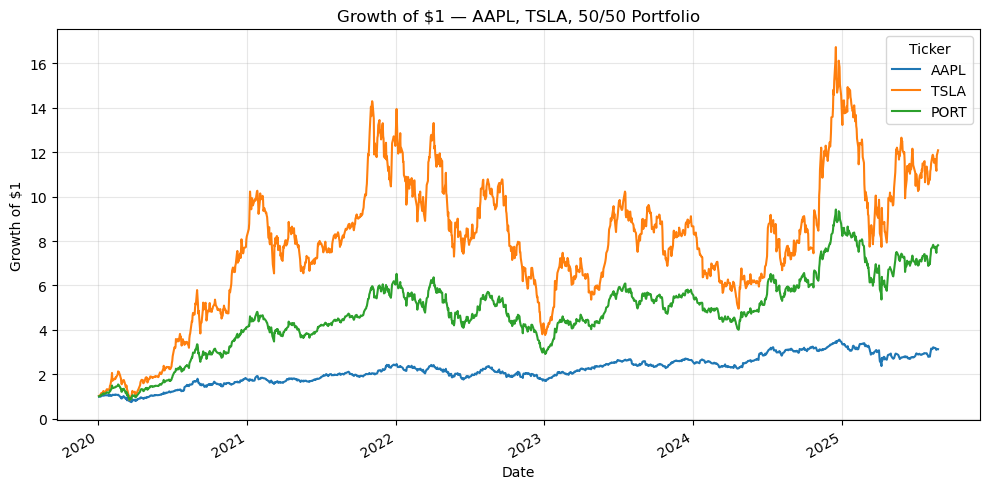

Portfolio σ (annualized): 0.442
Portfolio Sharpe (annualized): 1.05


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

# Data
tickers = ["AAPL", "TSLA"]             
start = "2020-01-01"

prices = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"].dropna()

# Daily % returns
rets = prices.pct_change().dropna()

# 50/50 portfolio return
w = np.array([0.5, 0.5])
port_ret = rets.dot(w)
port_ret.name = "PORT"

# Cumulative growth of $1
cum_stocks = (1 + rets).cumprod()
cum_port = (1 + port_ret).cumprod()
plot_df = cum_stocks.assign(PORT=cum_port)

ax = plot_df.plot(figsize=(10, 5))
ax.set_title("Growth of $1 — AAPL, TSLA, 50/50 Portfolio")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick risk
port_vol = port_ret.std() * np.sqrt(252)
port_sharpe = (port_ret.mean() / port_ret.std()) * np.sqrt(252)

print(f"Portfolio σ (annualized): {port_vol:.3f}")
print(f"Portfolio Sharpe (annualized): {port_sharpe:.2f}")
